<a href="https://colab.research.google.com/github/953622243097/Resume/blob/main/MNIST_FASHION_DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from keras import preprocessing
from keras.models import Sequential
from keras.layers import Conv2D,Dropout,Dense,Flatten,Conv2DTranspose,BatchNormalization,LeakyReLU,Reshape
import tensorflow as tf

In [ ]:
df = pd.read_csv("/content/fashion-mnist_test[1].csv")

In [ ]:
df


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103.0,87.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,0,0,0,0,0,0,...,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,0,0,0,0,14,53,99,...,0.0,0.0,0.0,0.0,63.0,53.0,31.0,0.0,0.0,0.0
3,2,0,0,0,0,0,0,0,0,0,...,137.0,126.0,140.0,0.0,133.0,224.0,222.0,56.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1881,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1882,6,0,0,0,0,0,0,0,0,20,...,35.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1883,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1884,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train = df.drop('label', axis = 1).head(50000)
y_train = df['label'].head(50000)
y_train

,label
0,0
1,1
2,2
3,2
4,3
5,2
6,8
7,6
8,5
9,0


In [ ]:
X_test = df.drop('label', axis = 1).tail(10000)
X_test = X_test.values
y_test = df['label'].tail(10000)
X_train = X_train.values
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)
print(X_train.shape)

(1886, 28, 28, 1)


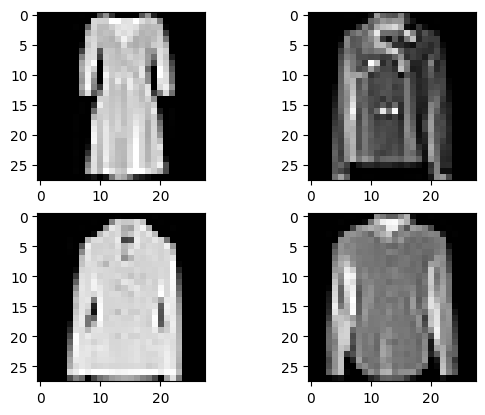

In [ ]:
fig,axe=plt.subplots(2,2)
idx = 10
for i in range(2):
    for j in range(2):
        axe[i,j].imshow(X_train[idx].reshape(28,28),cmap='gray')
        idx+=1

In [ ]:
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=[28, 28]),
tf.keras.layers.Dense(300, activation="tanh"),
tf.keras.layers.Dense(100, activation="tanh"),
tf.keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
59/59 [==============================] - 1s 12ms/step - loss: nan - accuracy: 0.2619 - val_loss: nan - val_accuracy: 0.0992
Epoch 2/30
59/59 [==============================] - 0s 7ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 3/30
59/59 [==============================] - 1s 12ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 4/30
59/59 [==============================] - 1s 14ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 5/30
59/59 [==============================] - 1s 12ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 6/30
59/59 [==============================] - 1s 13ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 7/30
59/59 [==============================] - 1s 11ms/step - loss: nan - accuracy: 0.0992 - val_loss: nan - val_accuracy: 0.0992
Epoch 8/30
59/59 [==============================] - 0s 7

In [ ]:
model.evaluate(X_test, y_test)

59/59 [==============================] - 0s 3ms/step - loss: nan - accuracy: 0.0992


[nan, 0.09915164113044739]